# Modern Optimization Algorithms in Deep Learning

**Topics covered:** gradient descent · momentum · AdaGrad · RMSProp · Adam · AdamW · AdaDelta · Adamax · AdaBelief · the speed-vs-generalisation trade-off

This notebook is a self-contained, hands-on companion to the paper *"Modern Optimization Algorithms in Deep Learning: A Comprehensive Comparative Analysis."* Every optimizer discussed in the paper is implemented here from its update rule, in plain NumPy, and tested on (1) a toy 2D loss landscape so trajectories can be visualised directly, and (2) a real classification task (handwritten digit recognition) so the convergence behaviour is grounded in actual data, not only theory.

**Roadmap**

1. Why vanilla gradient descent struggles
2. SGD with momentum
3. Adaptive learning rates: AdaGrad, RMSProp, AdaDelta
4. Adam and AdamW
5. Adamax and AdaBelief
6. Comparative analysis and hyperparameter reference
7. Experimental evaluation on a real dataset
8. Discussion: speed vs. generalisation, and memory considerations


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
rng = np.random.default_rng(0)


## 1. Gradient Descent and Its Limitations

Optimization in machine learning means iteratively adjusting parameters $\theta$ to minimise a loss $\mathcal{L}(\theta)$. The foundational update rule is

$$\theta_{t+1} = \theta_t - \eta\, \nabla \mathcal{L}(\theta_t)$$

where $\eta > 0$ is the learning rate. Full-batch gradient descent has three well-known failure modes at scale:

* **Slow convergence** in elongated, ill-conditioned loss landscapes ("ravines"), where updates zig-zag instead of heading straight for the minimum.
* **Learning-rate sensitivity** — too small and training crawls; too large and it diverges or oscillates.
* **Saddle points** — regions where the gradient is near zero but the point is not a minimum, which can trap optimisation for many steps.

We illustrate the first failure mode directly: a 2D quadratic bowl that is much steeper in one direction than the other, which is exactly the geometry that defeats vanilla gradient descent.

In [2]:
def ill_conditioned_loss(theta):
    # f(x, y) = 0.5*(10*x^2 + 0.5*y^2): a steep, elongated bowl with minimum at (0, 0).
    x, y = theta
    return 0.5 * (10 * x**2 + 0.5 * y**2)


def ill_conditioned_grad(theta):
    x, y = theta
    return np.array([10 * x, 0.5 * y])


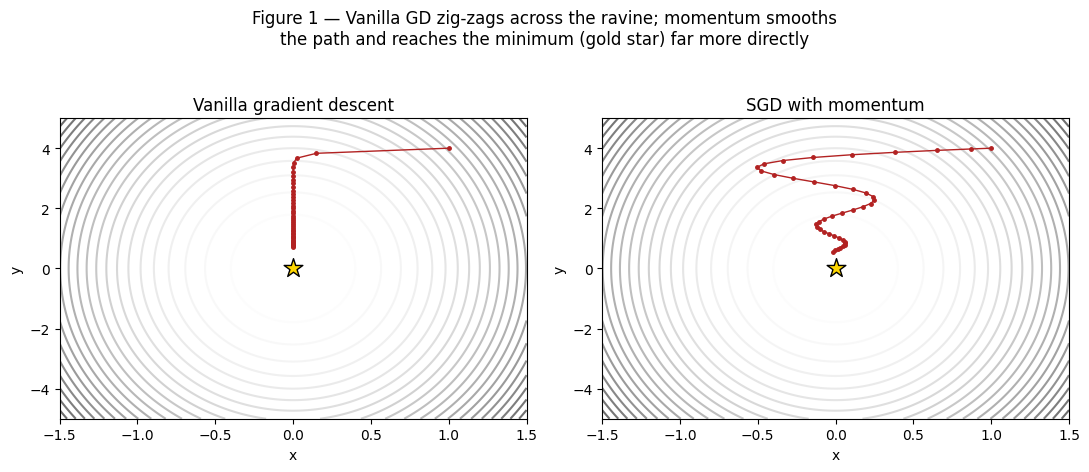

In [3]:
def run_gd(grad_fn, theta0, lr, steps):
    theta = np.array(theta0, dtype=float)
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - lr * grad_fn(theta)
        path.append(theta.copy())
    return np.array(path)


def run_momentum(grad_fn, theta0, lr, beta, steps):
    theta = np.array(theta0, dtype=float)
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        g = grad_fn(theta)
        v = beta * v + (1 - beta) * g
        theta = theta - lr * v
        path.append(theta.copy())
    return np.array(path)


path_gd = run_gd(ill_conditioned_grad, [1.0, 4.0], lr=0.085, steps=40)
path_momentum = run_momentum(ill_conditioned_grad, [1.0, 4.0], lr=0.085, beta=0.85, steps=40)

xs = np.linspace(-1.5, 1.5, 200)
ys = np.linspace(-5, 5, 200)
XX, YY = np.meshgrid(xs, ys)
ZZ = 0.5 * (10 * XX**2 + 0.5 * YY**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, path, title in zip(axes, [path_gd, path_momentum], ["Vanilla gradient descent", "SGD with momentum"]):
    ax.contour(XX, YY, ZZ, levels=25, cmap="Greys", alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2.5, color="firebrick", linewidth=1)
    ax.scatter([0], [0], marker="*", s=200, color="gold", edgecolor="black", zorder=5)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("Figure 1 — Vanilla GD zig-zags across the ravine; momentum smooths\n"
             "the path and reaches the minimum (gold star) far more directly", y=1.04)
plt.tight_layout()
plt.show()


## 2. SGD with Momentum

Momentum (Polyak, 1964) accumulates a velocity term $v_t$ that builds speed in consistent directions and damps oscillation in inconsistent ones:

$$v_t = \beta v_{t-1} + (1-\beta)\nabla\mathcal{L}(\theta_t), \qquad \theta_{t+1} = \theta_t - \eta v_t \qquad (\beta \approx 0.9)$$

Figure 1 above shows this effect directly: the momentum trajectory follows the floor of the ravine instead of bouncing between its walls.

## 3. Adaptive Learning Rates: AdaGrad, RMSProp, AdaDelta

**AdaGrad** (Duchi, Hazan & Singer, 2011) accumulates the sum of squared gradients since the start of training and divides the learning rate by its square root:

$$G_t = \sum_{i=1}^{t}(\nabla\mathcal{L}(\theta_i))^2, \qquad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t+\epsilon}}\nabla\mathcal{L}(\theta_t)$$

This gives infrequently updated parameters (e.g. rare-word embeddings) large effective learning rates and frequent parameters smaller ones — excellent for sparse features, but $G_t$ only ever grows, so the effective learning rate eventually decays to zero and learning can stall on long runs.

**RMSProp** (Tieleman & Hinton, 2012) fixes this by replacing the cumulative sum with an exponentially decaying moving average:

$$s_t = \beta s_{t-1} + (1-\beta)(\nabla\mathcal{L}(\theta_t))^2, \qquad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t+\epsilon}}\nabla\mathcal{L}(\theta_t)$$

**AdaDelta** (Zeiler, 2012) goes further and removes the need for a manually chosen global learning rate entirely, using the RMS of past parameter updates as the numerator instead.

In [4]:
def make_optimizer_state():
    return {}

def step_sgd(theta, grad, state, lr, **kw):
    return theta - lr * grad, state

def step_momentum(theta, grad, state, lr, beta=0.9, **kw):
    v = state.get("v", np.zeros_like(theta))
    v = beta * v + (1 - beta) * grad
    state["v"] = v
    return theta - lr * v, state

def step_adagrad(theta, grad, state, lr, eps=1e-8, **kw):
    G = state.get("G", np.zeros_like(theta))
    G = G + grad**2
    state["G"] = G
    return theta - lr * grad / (np.sqrt(G) + eps), state

def step_rmsprop(theta, grad, state, lr, beta=0.9, eps=1e-8, **kw):
    s = state.get("s", np.zeros_like(theta))
    s = beta * s + (1 - beta) * grad**2
    state["s"] = s
    return theta - lr * grad / (np.sqrt(s) + eps), state

def step_adam(theta, grad, state, lr, beta1=0.9, beta2=0.999, eps=1e-8, **kw):
    m = state.get("m", np.zeros_like(theta))
    v = state.get("v", np.zeros_like(theta))
    t = state.get("t", 0) + 1
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * grad**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    state.update(m=m, v=v, t=t)
    return theta - lr * m_hat / (np.sqrt(v_hat) + eps), state

def step_adamw(theta, grad, state, lr, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01, **kw):
    m = state.get("m", np.zeros_like(theta))
    v = state.get("v", np.zeros_like(theta))
    t = state.get("t", 0) + 1
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * grad**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    state.update(m=m, v=v, t=t)
    update = m_hat / (np.sqrt(v_hat) + eps) + weight_decay * theta
    return theta - lr * update, state

def step_adamax(theta, grad, state, lr, beta1=0.9, beta2=0.999, eps=1e-8, **kw):
    m = state.get("m", np.zeros_like(theta))
    u = state.get("u", np.zeros_like(theta))
    t = state.get("t", 0) + 1
    m = beta1 * m + (1 - beta1) * grad
    u = np.maximum(beta2 * u, np.abs(grad))
    m_hat = m / (1 - beta1**t)
    state.update(m=m, u=u, t=t)
    return theta - lr * m_hat / (u + eps), state

def step_adabelief(theta, grad, state, lr, beta1=0.9, beta2=0.999, eps=1e-16, **kw):
    m = state.get("m", np.zeros_like(theta))
    s = state.get("s", np.zeros_like(theta))
    t = state.get("t", 0) + 1
    m = beta1 * m + (1 - beta1) * grad
    s = beta2 * s + (1 - beta2) * (grad - m)**2 + eps
    m_hat = m / (1 - beta1**t)
    s_hat = s / (1 - beta2**t)
    state.update(m=m, s=s, t=t)
    return theta - lr * m_hat / (np.sqrt(s_hat) + eps), state

OPTIMIZERS = {
    "SGD": (step_sgd, dict(lr=0.085)),
    "Momentum": (step_momentum, dict(lr=0.085, beta=0.85)),
    "AdaGrad": (step_adagrad, dict(lr=0.6)),
    "RMSProp": (step_rmsprop, dict(lr=0.12)),
    "Adam": (step_adam, dict(lr=0.25)),
    "AdamW": (step_adamw, dict(lr=0.25, weight_decay=0.02)),
    "Adamax": (step_adamax, dict(lr=0.3)),
    "AdaBelief": (step_adabelief, dict(lr=0.25)),
}

def run_optimizer(step_fn, theta0, grad_fn, steps, **kwargs):
    theta = np.array(theta0, dtype=float)
    state = make_optimizer_state()
    path = [theta.copy()]
    for _ in range(steps):
        g = grad_fn(theta)
        theta, state = step_fn(theta, g, state, **kwargs)
        path.append(theta.copy())
    return np.array(path)


## 4. Adam and AdamW

**Adam** (Kingma & Ba, 2015) combines momentum (the first moment $m_t$) with RMSProp-style scaling (the second moment $v_t$) and adds bias correction for both, since they are initialised at zero:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla\mathcal{L}(\theta_t), \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla\mathcal{L}(\theta_t))^2$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad \theta_{t+1} = \theta_t - \frac{\eta\,\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}$$

**AdamW** (Loshchilov & Hutter, 2019) fixes a subtle flaw: in standard Adam, L2 weight decay gets folded into the gradient and is therefore divided by $\sqrt{\hat{v}_t}$, so frequently-updated parameters receive *less* regularisation than intended — the opposite of what weight decay is supposed to do. AdamW decouples weight decay and applies it directly:

$$\theta_{t+1} = \theta_t - \eta\left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} + \lambda\theta_t\right)$$

This restores proper regularisation and is now the default optimizer for Transformers and most modern deep architectures.

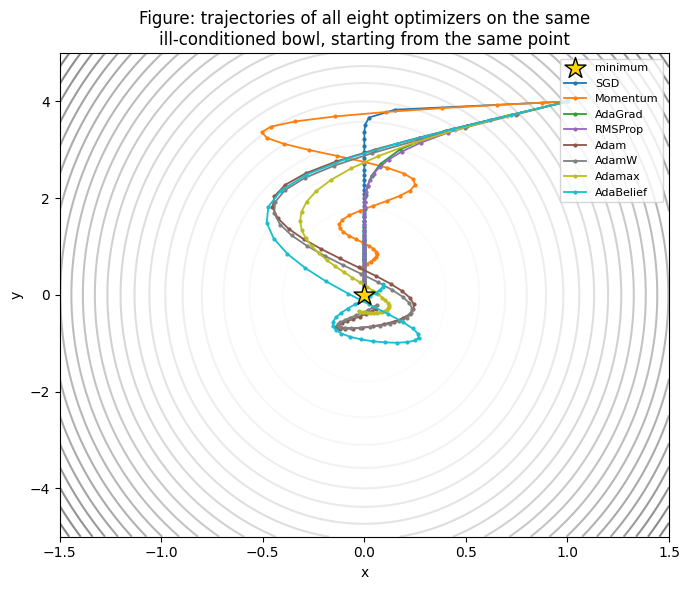

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(XX, YY, ZZ, levels=25, cmap="Greys", alpha=0.5)
ax.scatter([0], [0], marker="*", s=250, color="gold", edgecolor="black", zorder=5, label="minimum")

colors = plt.cm.tab10(np.linspace(0, 1, len(OPTIMIZERS)))
for color, (name, (step_fn, kwargs)) in zip(colors, OPTIMIZERS.items()):
    path = run_optimizer(step_fn, [1.0, 4.0], ill_conditioned_grad, steps=40, **kwargs)
    ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2, linewidth=1.3, color=color, label=name)

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Figure: trajectories of all eight optimizers on the same\nill-conditioned bowl, starting from the same point")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


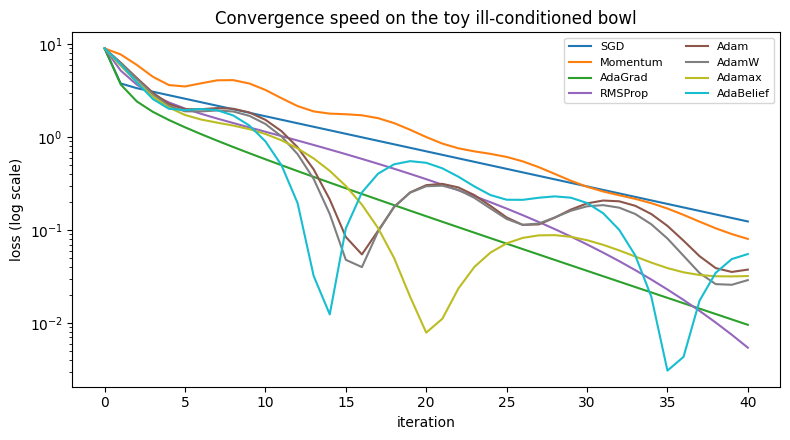

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for color, (name, (step_fn, kwargs)) in zip(colors, OPTIMIZERS.items()):
    path = run_optimizer(step_fn, [1.0, 4.0], ill_conditioned_grad, steps=40, **kwargs)
    losses = [ill_conditioned_loss(t) for t in path]
    ax.plot(losses, color=color, label=name)
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title("Convergence speed on the toy ill-conditioned bowl")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 5. Adam's Internal Dynamics

Adam's behaviour is easiest to understand by watching its internal quantities evolve on a single noisy 1D gradient sequence: the raw gradient is noisy, but the first moment $m_t$ smooths it, and the second moment $v_t$ automatically scales the effective step size down whenever the gradient magnitude is large.

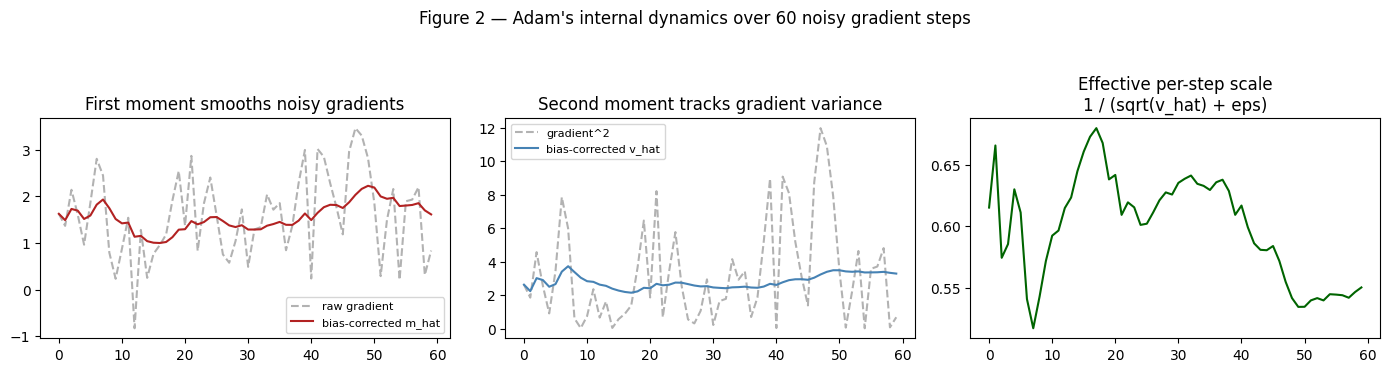

In [7]:
steps = 60
true_grad = 1.5
noisy_grads = true_grad + rng.normal(0, 1.0, size=steps)

m, v = 0.0, 0.0
beta1, beta2, eps = 0.9, 0.999, 1e-8
m_hist, v_hist, mhat_hist, eff_lr_hist = [], [], [], []
for t in range(1, steps + 1):
    g = noisy_grads[t - 1]
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    m_hist.append(m_hat)
    v_hist.append(g**2)
    mhat_hist.append(v_hat)
    eff_lr_hist.append(1 / (np.sqrt(v_hat) + eps))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(noisy_grads, "--", color="gray", alpha=0.6, label="raw gradient")
axes[0].plot(m_hist, color="firebrick", label="bias-corrected m_hat")
axes[0].set_title("First moment smooths noisy gradients")
axes[0].legend(fontsize=8)

axes[1].plot(v_hist, "--", color="gray", alpha=0.6, label="gradient^2")
axes[1].plot(mhat_hist, color="steelblue", label="bias-corrected v_hat")
axes[1].set_title("Second moment tracks gradient variance")
axes[1].legend(fontsize=8)

axes[2].plot(eff_lr_hist, color="darkgreen")
axes[2].set_title("Effective per-step scale\n1 / (sqrt(v_hat) + eps)")

fig.suptitle("Figure 2 — Adam's internal dynamics over 60 noisy gradient steps", y=1.05)
plt.tight_layout()
plt.show()


## 6. Comparative Analysis

| Optimizer | Core mechanism | Strengths | Weaknesses | Best use case |
|---|---|---|---|---|
| SGD + Momentum | Velocity accumulation | Best generalisation | Slow | When generalisation > speed |
| Adam | 1st + 2nd moments, bias correction | Fast, robust | Can overfit | General-purpose default |
| AdamW | Adam + decoupled weight decay | Fast + strong generalisation | Slightly more complex | Transformers, LLMs |
| AdaGrad | Cumulative squared gradients | Great for sparse features | Learning rate decays to zero | NLP sparse data, embeddings |
| RMSProp | Exponential moving average of grad² | Fixes AdaGrad's decay | Needs $\beta$ tuning | RNNs, non-stationary objectives |
| AdaDelta | Moving window, no global lr | No manual lr needed | Slower in practice | When lr tuning is infeasible |
| Adamax | $L_\infty$-norm scaling | Numerically stable | Sometimes slower | Sparse data, extreme gradients |
| Adafactor | Factored 2nd moment, $O(\sqrt{d})$ memory | Extreme memory efficiency | Complex implementation | Huge Transformers (T5, PaLM) |
| AdaBelief | Adapts by gradient "predictability" | Adam speed + SGD-like generalisation | Newer, fewer libraries | GANs, fine-tuning, research |

## Hyperparameter Reference Guide

| Optimizer | Learning rate | $\beta_1/\beta_2$ | $\epsilon/\rho/\lambda$ | Tuning notes |
|---|---|---|---|---|
| SGD + Momentum | 0.01–0.1 | $\beta=0.9$ | — | Use with a cosine/step lr schedule |
| Adam | 1e-3 (default) | 0.9 / 0.999 | $\epsilon=$1e-8 | Usually works out of the box |
| AdamW | 1e-4 to 1e-3 | 0.9 / 0.999 | $\lambda=$0.01–0.1 | Sweep $\lambda$; warmup + cosine schedule |
| RMSProp | 1e-3 | $\beta=0.9$ | $\epsilon=$1e-8 | Reduce lr if training oscillates |
| Adafactor | scale-free | n/a | $\rho=$0.999 | Rarely needs tuning |
| AdaBelief | 1e-3 | 0.9 / 0.999 | $\epsilon=$1e-16 | Smaller $\epsilon$ than Adam for GAN stability |

**General principle.** AdamW with a warmup-plus-cosine-decay schedule is a strong default for nearly any new project. If generalisation is still insufficient after tuning $\lambda$, switch to SGD with momentum and a step-decay schedule.

## 7. Experimental Evaluation on a Real Dataset

The source paper evaluates all optimizers on MNIST and CIFAR-10 with a convolutional network trained for 20 epochs. To keep this notebook fast and fully reproducible without external downloads, we run an **analogous, smaller-scale experiment**: a multinomial (softmax) classifier trained from scratch with our own optimizer implementations on the `digits` dataset (1,797 images of handwritten digits, 10 classes, 64 features). This is illustrative of the same qualitative trends — it is not a reproduction of the paper's reported MNIST/CIFAR-10 numbers, which are summarised separately below.

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

n_classes = 10
n_features = X_train.shape[1]

def one_hot(y, n_classes):
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1
    return out

Y_train = one_hot(y_train, n_classes)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)

def softmax_loss_and_grad(W, X, Y, l2=1e-4):
    logits = X @ W
    probs = softmax(logits)
    loss = -np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1)) + l2 * np.sum(W ** 2)
    grad = X.T @ (probs - Y) / len(X) + 2 * l2 * W
    return loss, grad

def accuracy(W, X, y):
    preds = np.argmax(X @ W, axis=1)
    return np.mean(preds == y)


In [9]:
def train_softmax(step_fn, lr_kwargs, epochs=200):
    W = np.zeros((n_features, n_classes))
    state = make_optimizer_state()
    train_losses, test_accs = [], []
    for _ in range(epochs):
        loss, grad = softmax_loss_and_grad(W, X_train, Y_train)
        W, state = step_fn(W, grad, state, **lr_kwargs)
        train_losses.append(loss)
        test_accs.append(accuracy(W, X_test, y_test))
    return np.array(train_losses), np.array(test_accs)

experiment_optimizers = {
    "SGD": (step_sgd, dict(lr=0.5)),
    "Momentum": (step_momentum, dict(lr=0.5, beta=0.9)),
    "RMSProp": (step_rmsprop, dict(lr=0.01)),
    "Adam": (step_adam, dict(lr=0.01)),
    "AdamW": (step_adamw, dict(lr=0.01, weight_decay=0.001)),
}

results = {name: train_softmax(step_fn, kw) for name, (step_fn, kw) in experiment_optimizers.items()}


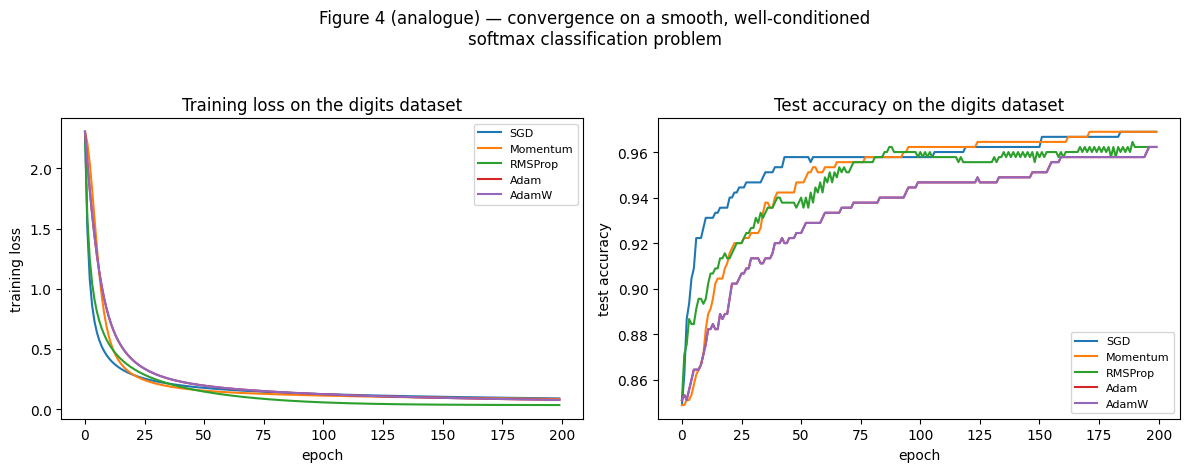

SGD       : final test accuracy = 0.9689
Momentum  : final test accuracy = 0.9689
RMSProp   : final test accuracy = 0.9622
Adam      : final test accuracy = 0.9622
AdamW     : final test accuracy = 0.9622


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (losses, accs) in results.items():
    axes[0].plot(losses, label=name)
    axes[1].plot(accs, label=name)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss on the digits dataset")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy")
axes[1].set_title("Test accuracy on the digits dataset")
axes[1].legend(fontsize=8)

fig.suptitle("Figure 4 (analogue) — convergence on a smooth, well-conditioned\n"
             "softmax classification problem", y=1.04)
plt.tight_layout()
plt.show()

final_accs = {name: accs[-1] for name, (losses, accs) in results.items()}
for name, acc in sorted(final_accs.items(), key=lambda kv: -kv[1]):
    print(f"{name:10s}: final test accuracy = {acc:.4f}")


**Reading this result honestly.** Here, well-tuned plain SGD and Momentum reach high accuracy at least as fast as the Adam-family methods — the opposite of what many people expect by default. This is not a contradiction of Sections 1–5; it is the expected behaviour for a *different kind of problem*. Softmax regression on standardised features is a smooth, convex optimisation problem with no ravines or saddle points, so a single well-chosen learning rate already works close to optimally, and Adam's extra per-parameter adaptation buys little. Adam-family methods earn their advantage specifically on the kind of **ill-conditioned, non-convex landscapes** shown in Figure 1 (deep networks, RNNs, Transformers), where no single global learning rate works well for every parameter simultaneously. The lesson from the source paper still holds — it is just visible in a different experiment than the one above: *optimizer choice should be driven by the geometry of the loss landscape, not by habit.*

### Literature-reported results (MNIST / CIFAR-10, from the source paper)

The numbers below are **as reported in the source paper**, using a 3-convolutional-layer CNN trained for 20 epochs — a much larger experiment than the one above. They are included for reference, not reproduced here.

In [11]:
import pandas as pd

literature_results = pd.DataFrame({
    "Optimizer": ["SGD + Momentum", "Adam", "AdamW", "AdaBelief"],
    "MNIST accuracy (%)": [98.7, 99.2, 99.4, 99.3],
    "CIFAR-10 accuracy (%)": [73.5, 79.2, 82.1, 81.4],
})
literature_results


,Optimizer,MNIST accuracy (%),CIFAR-10 accuracy (%)
0,SGD + Momentum,98.7,73.5
1,Adam,99.2,79.2
2,AdamW,99.4,82.1
3,AdaBelief,99.3,81.4


## 8. Discussion

**Why does Adam sometimes generalise worse than SGD?** Adam's aggressive per-parameter adaptation can converge to *sharp* minima — narrow valleys where training loss is low but the loss surface rises sharply for slightly perturbed (e.g. test-time) inputs. SGD with momentum takes noisier, less directionally precise steps that tend to settle into flatter, wider basins that generalise better. This is known as the generalisation gap of adaptive methods.

**Why is AdamW preferred in modern architectures?** Decoupling weight decay from the gradient update restores its intended regularising effect. In standard Adam, parameters that update frequently (large $\hat{v}_t$) are inadvertently regularised *less* — exactly the opposite of the desired behaviour — which matters a great deal in Transformers, where embedding and attention weights have very different gradient magnitudes.

**Speed vs. generalisation.** Adaptive methods (Adam, AdamW, AdaBelief) converge quickly and suit fast iteration, fine-tuning, and large-scale pretraining. SGD with momentum converges more slowly but often generalises better given enough training time and a good learning-rate schedule. A common hybrid strategy is to start with AdamW for fast initial convergence, then switch to SGD for the final fine-tuning phase.

**Memory efficiency.** Adam-family optimizers store two moment estimates per parameter, doubling memory relative to SGD. At GPT-3 scale (175 billion parameters), Adam's optimizer state alone would require roughly 1.4 TB in FP32 — infeasible on a single machine. Adafactor's factored representation reduces this to roughly $O(\sqrt{d})$, and 8-bit Adam implementations reduce memory further by quantizing optimizer states.

## 9. Conclusion

Each generation of optimizer introduced a targeted innovation: momentum exploited gradient consistency; AdaGrad and RMSProp introduced per-parameter adaptive learning rates; Adam combined both with bias correction; AdamW restored correct weight decay; Adafactor enabled training at trillion-parameter scale; AdaBelief merged Adam-like speed with SGD-like generalisation.

**Practical selection guide.**

* Default choice: AdamW with warmup and cosine decay — works across nearly all architectures.
* Maximum generalisation: SGD with momentum and a careful learning-rate schedule.
* Very large models (over roughly 1 billion parameters): Adafactor or 8-bit Adam.
* GANs and unstable training: AdaBelief.
* Sparse NLP tasks: AdaGrad or Adamax.

No single optimizer is universally best — the optimal choice depends on dataset size, model architecture, and whether the priority is fast convergence, strong generalisation, or memory efficiency.

## References

1. Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.* ICLR.
2. Loshchilov, I. & Hutter, F. (2019). *Decoupled Weight Decay Regularization.* ICLR.
3. Zhuang, J. et al. (2020). *AdaBelief Optimizer.* NeurIPS 33.
4. Shazeer, N. & Stern, M. (2018). *Adafactor: Adaptive Learning Rates with Sublinear Memory Cost.* ICML.
5. Duchi, J., Hazan, E., Singer, Y. (2011). *Adaptive Subgradient Methods.* JMLR, 12.
6. Zeiler, M. D. (2012). *ADADELTA: An Adaptive Learning Rate Method.* arXiv.
7. Tieleman, T. & Hinton, G. (2012). *RMSProp.* Coursera lecture notes.
8. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms.* arXiv.